# Stats

This notebook analyzes multiple aspects of KuaiRec datasets to better understand user behavior and data characteristics, including:
- Data density and train/evaluation split consistency
- Interaction distributions per user and video
- Temporal patterns such as daily, weekly, and hourly interaction trends
- Engagement metrics including watch ratios and play durations
- Class distribution of liked vs. unliked videos and implications on sparsity

We begin by importing and loading our datasets, cleaning by dropping NaN values and duplicate rows (which account for about 8% and 4% of the data).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.utils import *

In [2]:
big_matrix = read_matrix("big", "big_matrix")
small_matrix = read_matrix("small", "small_matrix")

--- Reading big matrix ---
Loading...
Cleaning...
7.71% of the data has been filtered out
--- Readed in 19.1931s ---
--- Reading small matrix ---
Loading...
Cleaning...
3.89% of the data has been filtered out
--- Readed in 6.5052s ---


---

# 1. Density and Train / evaluation

## 1.1 Train / Evaluation

This code checks the percentage of `user_id` and `video_id` in the validation set (`small_matrix`) that also exist in the training set (`big_matrix`).

In [3]:
def test_col(col):
    train_users = set(big_matrix[col].unique().tolist())
    val_users = set(small_matrix[col].unique().tolist())

    data = min(len(train_users), len(val_users))
    print(f"Percentage of {col} in small_matrix that are in big_matrix:", len(train_users.intersection(val_users)) / data * 100)

test_col("user_id")
test_col("video_id")

Percentage of user_id in small_matrix that are in big_matrix: 100.0
Percentage of video_id in small_matrix that are in big_matrix: 100.0


Both `user_id` and `video_id` have 100% overlap between training and validation sets. This means the model won't face cold-start issues for users or items during validation.

---

This code finds the number of identical `(user_id, video_id)` pairs shared between the training (`big_matrix`) and validation (`small_matrix`) sets using an inner join.

In [5]:
common_rows = pd.merge(big_matrix[['user_id', 'video_id']], 
                       small_matrix[['user_id', 'video_id']], 
                       on=['user_id', 'video_id'],
                       how='inner')

print("Number of common rows:", len(common_rows))

Number of common rows: 0


There are 0 common `(user_id, video_id)` pairs between the two sets. This ensures a clean separation — the model is evaluated on completely new interactions, preventing data leakage.

---

## 1.2 Density

This code computes the interaction **density** for both training and evaluation sets. Density is defined as:

$$\text{Density} = \frac{\text{Number of interactions}}{\text{Number of users} \times \text{Number of items}}$$

In [4]:
print("Density of training:", len(big_matrix) / (big_matrix["user_id"].nunique() * big_matrix["video_id"].nunique()))
print("Density of eval:", len(small_matrix) / (small_matrix["user_id"].nunique() * small_matrix["video_id"].nunique()))

Density of training: 0.15022560234753846
Density of eval: 0.9574345757293216


**Training density (~0.15)**: Sparse data, typical — users interact with only a small subset of items.

**Evaluation density (~1.0)**: Nearly complete user-item matrix, suggesting that most users interacted with most items. This indicates a **dense validation set**, useful for evaluating ranking performance under full exposure.

---

# 2. Activity distribution

## 2.1 Distribution of User Activity

This plot shows the distribution of the number of interactions per user in the dataset. The x-axis represents the number of interactions each user has made, while the y-axis (in log scale) shows how many users fall into each interaction count bucket.

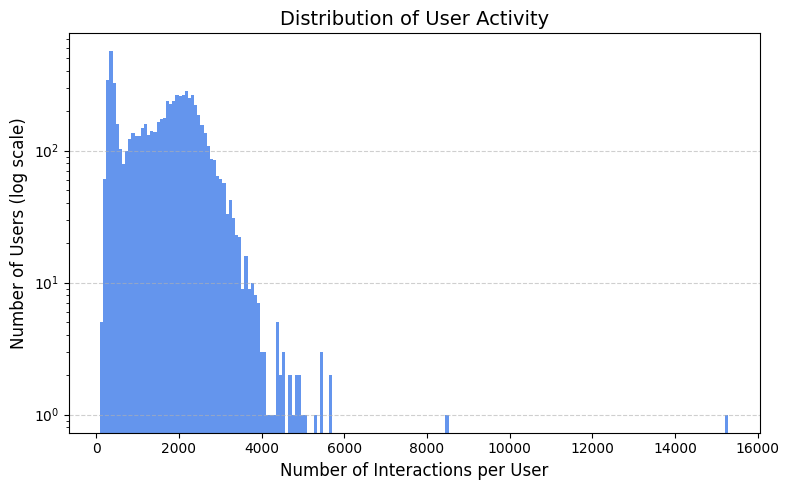

In [9]:
# Count number of interactions per user
user_interaction_counts = big_matrix['user_id'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
plt.hist(user_interaction_counts, bins=200, color='cornflowerblue', log=True)

plt.title('Distribution of User Activity', fontsize=14)
plt.xlabel('Number of Interactions per User', fontsize=12)
plt.ylabel('Number of Users (log scale)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

We can observe that most users have fewer than 4,000 interactions, with the frequency of users decreasing as interaction counts increase.

---

## 2.2 Distribution of Video Interaction Counts

This histogram illustrates how many times each video has been interacted with by users. The x-axis shows the number of interactions per video, while the y-axis (log scale) represents the count of videos within each interaction range.

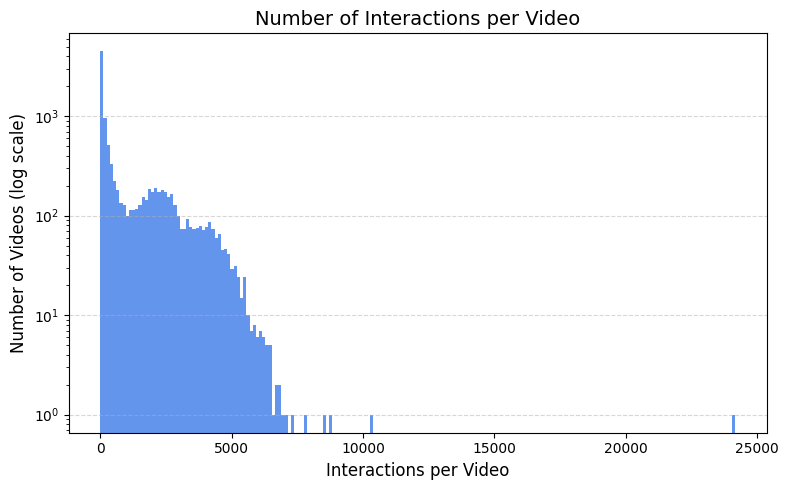

In [10]:
# Count interactions per video
video_interaction_counts = big_matrix['video_id'].value_counts()

# Plot histogram focused on videos with up to 100 interactions
plt.figure(figsize=(8, 5))
plt.hist(video_interaction_counts, bins=200, color='cornflowerblue', log=True)

plt.title('Number of Interactions per Video', fontsize=14)
plt.xlabel('Interactions per Video', fontsize=12)
plt.ylabel('Number of Videos (log scale)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Most videos have fewer than 7,000 interactions, with a steep drop-off beyond this point. This indicates that while some videos are very popular and receive many interactions, the majority have relatively low engagement. The distribution reflects a typical "long-tail" pattern seen in content consumption, where a few videos are highly popular, but most receive limited attention.

It may potentially biased collaborative-filtering system.

---

# 3. Temporal patterns

## 3.1 Pre-processing

We first correctly parse the timestamp field.

In [5]:
# Convert timestamp to datetime if needed (assuming UNIX timestamp)
big_matrix['time'] = pd.to_datetime(big_matrix['timestamp'], unit="s")

# Extract date (day precision)
big_matrix['date'] = big_matrix['time'].dt.date

---

## 3.2 Daily Number of User Interactions Over Time

The two plots show the daily count of user interactions with the system over the observation period. The first plot uses a linear scale, highlighting absolute changes in daily interactions, while the second uses a logarithmic scale to better capture relative fluctuations, especially on days with lower activity.

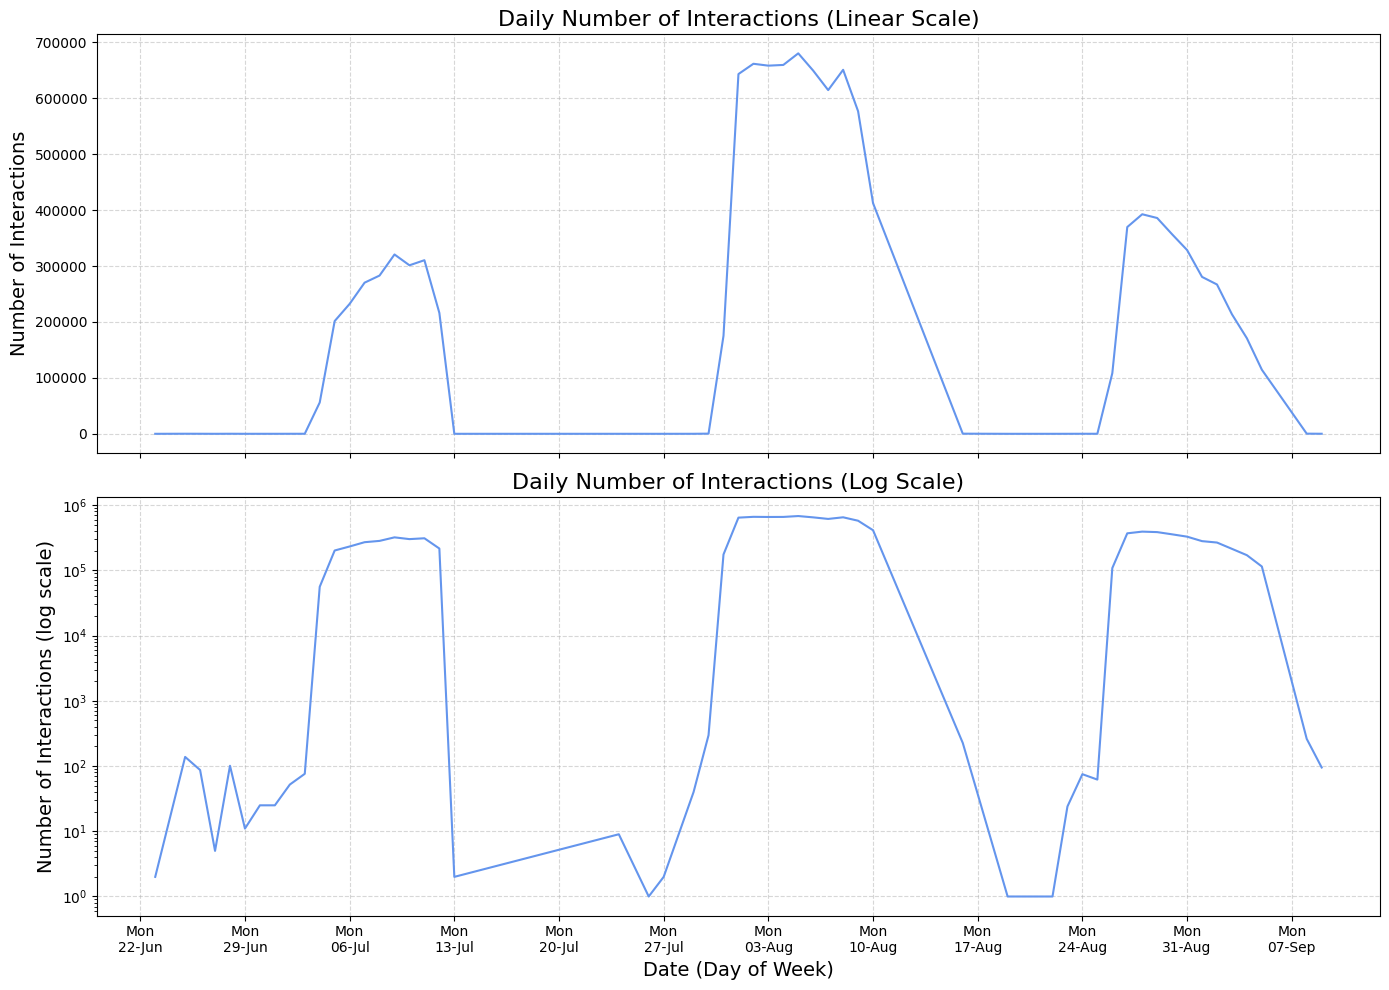

In [11]:
# Count interactions per hour
interactions_per_day = big_matrix.groupby('date').size()

dates = pd.to_datetime(interactions_per_day.index)

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Linear scale plot
axs[0].plot(dates, interactions_per_day, color='cornflowerblue', linewidth=1.5)
axs[0].set_title('Daily Number of Interactions (Linear Scale)', fontsize=16)
axs[0].set_ylabel('Number of Interactions', fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.5)

# Log scale plot
axs[1].plot(dates, interactions_per_day, color='cornflowerblue', linewidth=1.5)
axs[1].set_yscale('log')
axs[1].set_title('Daily Number of Interactions (Log Scale)', fontsize=16)
axs[1].set_xlabel('Date (Day of Week)', fontsize=14)
axs[1].set_ylabel('Number of Interactions (log scale)', fontsize=14)
axs[1].grid(True, linestyle='--', alpha=0.5)

# Format x-axis for both plots with day of week + date
for ax in axs:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))  # every Monday
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d-%b'))

plt.tight_layout()
plt.show()

We observe three notable peaks in user activity occurring in early July, early August, and late August. These spikes align closely with significant dates in China’s calendar, including:
- **July 1**: CPC Foundation Day, celebrating the founding of the Chinese Communist Party.
- **August 1**: PLA Day, marking the establishment of the People’s Liberation Army.

These days likely contribute to increased platform engagement as users have more leisure time. Additionally, these peaks may reflect broader seasonal usage patterns, such as the summer vacation period, when people generally have more free time for content consumption.

---

## 3.3 Number of Interactions by Hour of Day

This bar chart displays the total number of user interactions aggregated by each hour of the day (0–23). It helps us understand when users are most active on the platform during a typical day.

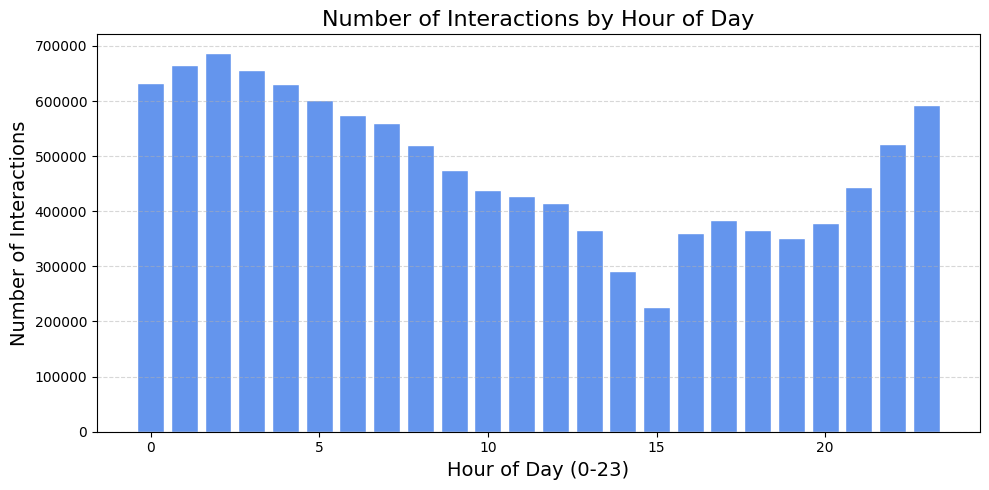

In [12]:
# Extract hour from datetime
big_matrix['hour'] = big_matrix['time'].dt.hour

# Count interactions per hour
interactions_per_hour = big_matrix.groupby('hour').size()

plt.figure(figsize=(10, 5))
plt.bar(interactions_per_hour.index, interactions_per_hour.values, color='cornflowerblue', edgecolor='white')
plt.title('Number of Interactions by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=14)
plt.ylabel('Number of Interactions', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The plot shows a clear peak in interactions during nighttime hours, with noticeably fewer interactions during the daytime. However, there is a caveat: the timestamps were converted assuming UNIX time without timezone adjustment, which may cause a mismatch in the actual local time. This means the observed peak might need to be shifted to correctly reflect user activity in the relevant time zone.

Despite this, the pattern suggests that users tend to be more active during evening or night periods, which is common for media consumption platforms as people engage more during their leisure hours after daytime commitments.

---

## 3.4 Number of Interactions by Day of the Week

This bar chart presents the total user interactions aggregated for each day of the week, ordered from Monday to Sunday. It reveals weekly patterns in platform usage.

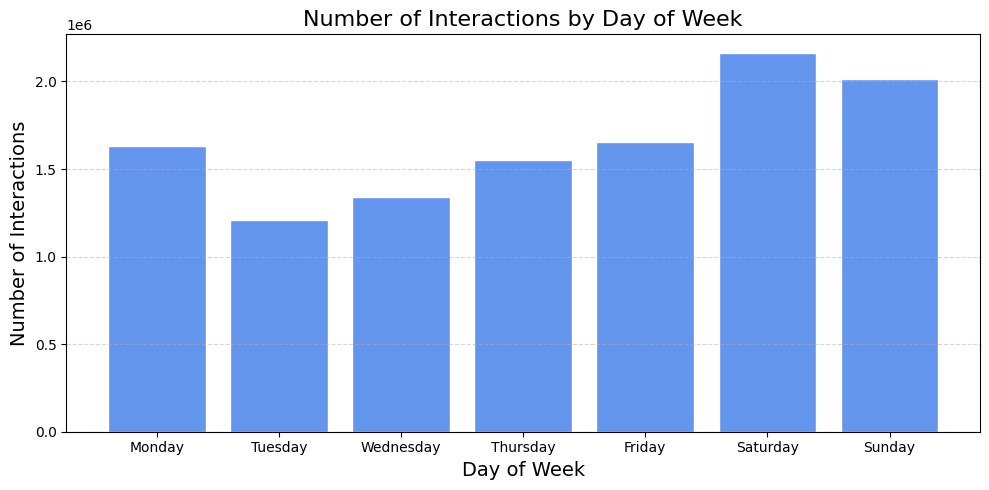

In [13]:
big_matrix['day_of_week'] = big_matrix['time'].dt.day_name()
interactions_per_dayofweek = big_matrix.groupby('day_of_week').size()

# Order days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
interactions_per_dayofweek = interactions_per_dayofweek.reindex(days_order)

plt.figure(figsize=(10, 5))
plt.bar(interactions_per_dayofweek.index, interactions_per_dayofweek.values, color='cornflowerblue', edgecolor='white')
plt.title('Number of Interactions by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=14)
plt.ylabel('Number of Interactions', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The pattern reveals that Monday has relatively high interaction counts, followed by a dip on Tuesday, and then a gradual increase through Wednesday, Thursday, and Friday. User activity peaks during the weekend, with Saturday and Sunday showing the highest interaction levels overall.

This suggests a weekly cycle where users are quite active at the start of the week, experience a midweek lull on Tuesday, and then ramp up activity again toward the weekend.


---

## 3.5 Heatmap of Interactions by Day of Week and Hour

This heatmap visualizes user interactions across different hours of the day and days of the week. Each cell shows the count of interactions for a specific hour and day, with color intensity indicating higher (dark blue) or lower (white) activity levels.

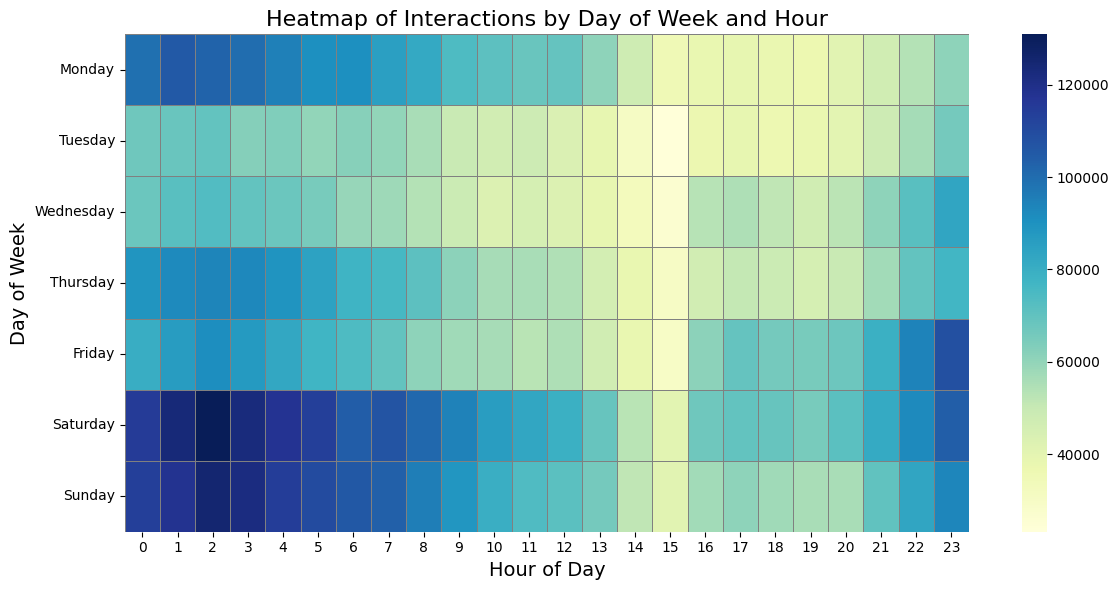

In [14]:
# Create pivot table of counts by day of week and hour
pivot = big_matrix.pivot_table(index=big_matrix['time'].dt.day_name(),
                               columns=big_matrix['time'].dt.hour,
                               values='user_id', aggfunc='count').reindex(days_order)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.5, linecolor='gray')
plt.title('Heatmap of Interactions by Day of Week and Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Day of Week', fontsize=14)
plt.tight_layout()
plt.show()

---

# 4. Watch ratio

## 4.1 Distribution of Watch Ratios (Clamped at 5)

This KDE plot shows the distribution of the `watch_ratio` feature, which represents how much of a video users watched relative to its total length. To improve visualization clarity, values were clamped at a maximum of 5, reducing the impact of extreme outliers and noise beyond this threshold.

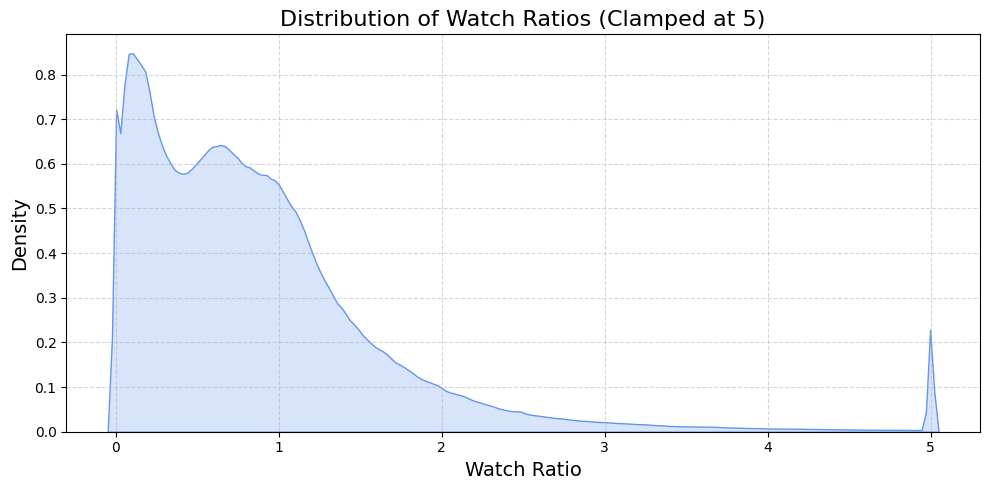

In [18]:
# Clamp watch_ratio to max=5 for visualization
clamped_ratio = big_matrix['watch_ratio'].clip(upper=5)

plt.figure(figsize=(10, 5))
sns.kdeplot(clamped_ratio, fill=True, color='cornflowerblue', bw_adjust=0.5)
plt.title('Distribution of Watch Ratios (Clamped at 5)', fontsize=16)
plt.xlabel('Watch Ratio', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The distribution reveals two distinct peaks at the beginning, followed by a gradual decline. This suggests that a large portion of users either watch very little or roughly the initial part of videos, with fewer users watching longer proportions continuously.

---

## 4.2 Distribution of Play Time

This histogram illustrates the distribution of play durations for user interactions, measured in seconds. The y-axis uses a logarithmic scale to better represent the wide range of play times and capture both frequent short plays and less common longer ones.

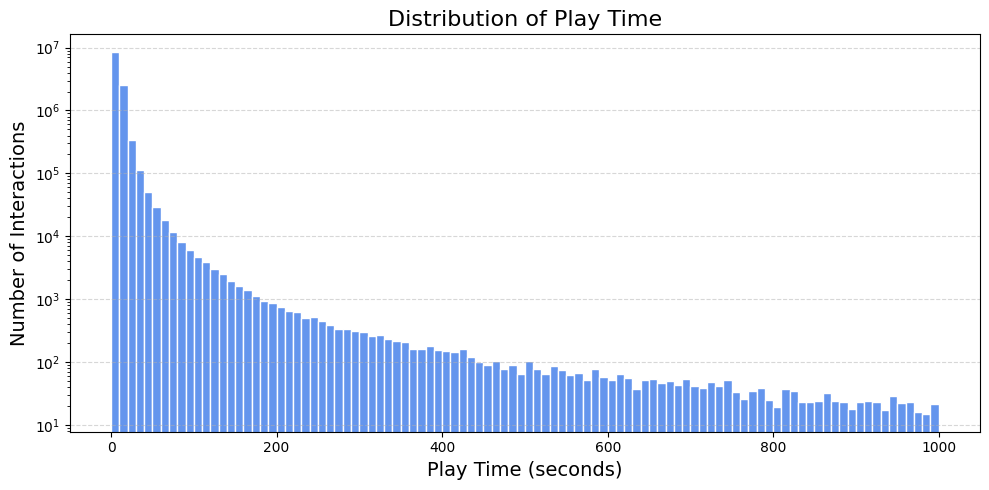

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(big_matrix['play_duration'] / 1000, bins=100, color='cornflowerblue', edgecolor='white', log=True)
plt.title('Distribution of Play Time', fontsize=16)
plt.xlabel('Play Time (seconds)', fontsize=14)
plt.ylabel('Number of Interactions', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

We observe a pronounced peak near zero seconds, indicating many interactions with very short play times—likely users quickly skipping or abandoning videos. After this peak, the frequency of interactions steadily decreases as play duration increases, reflecting fewer longer viewing sessions.

This pattern highlights the challenge of user attention and engagement, with a significant portion of interactions being very brief.

---

## 4.3 Distribution of Video Duration

This histogram depicts the distribution of video durations in seconds (converted from milliseconds), with the y-axis on a logarithmic scale to capture the full range of video lengths.

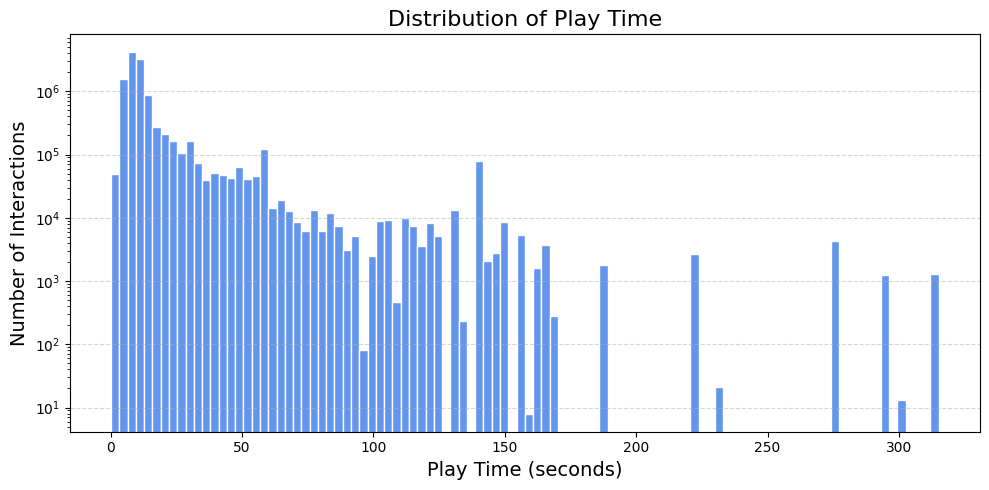

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(big_matrix['video_duration'] / 1000, bins=100, color='cornflowerblue', edgecolor='white', log=True)
plt.title('Distribution of Play Time', fontsize=16)
plt.xlabel('Play Time (seconds)', fontsize=14)
plt.ylabel('Number of Interactions', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The majority of videos are shorter than 150 seconds (2.5 minutes), indicating that most content is relatively brief. Beyond this point, the frequency of videos sharply decreases, showing a few longer videos as outliers.

This suggests the platform primarily hosts short-form content, which may influence user engagement patterns and should be considered when designing recommendation strategies.

---

# 5. Like distribution

## 5.1 Number of Likes per User

These histograms show the distribution of the number of "likes" (defined as interactions with `watch_ratio` ≥ 2) per user for both the training dataset (`big_matrix`) and the evaluation one (`small_matrix`). The x-axis represents how many liked interactions each user has, while the y-axis (log scale) shows the count of users with that many likes.

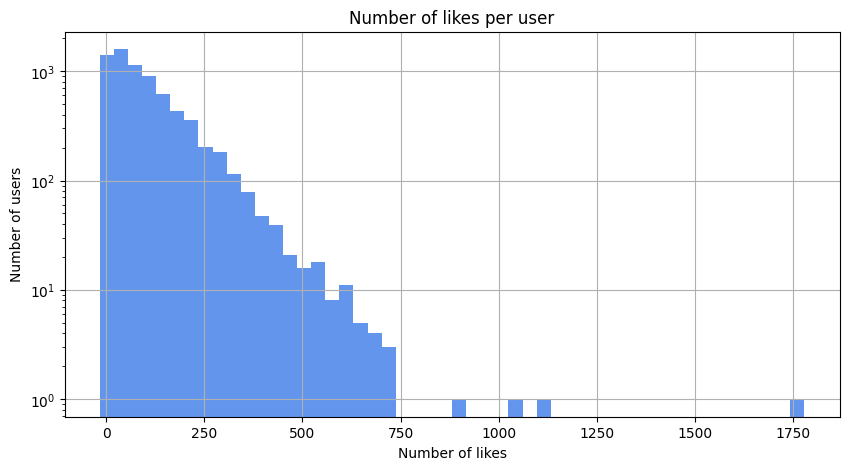

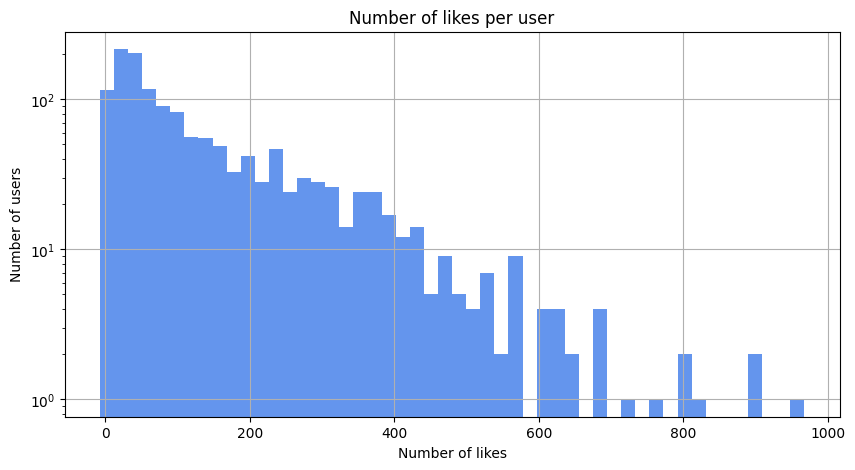

In [42]:
liked = big_matrix[big_matrix["watch_ratio"] >= 2].groupby("user_id").size()
plt.figure(figsize=(10, 5))
plt.hist(liked, bins=50, align='left', color='cornflowerblue', log=True)
plt.xlabel('Number of likes')
plt.ylabel('Number of users')
plt.title('Number of likes per user')
plt.grid(True)
plt.show()

liked = small_matrix[small_matrix["watch_ratio"] >= 2].groupby("user_id").size()
plt.figure(figsize=(10, 5))
plt.hist(liked, bins=50, align='left', color='cornflowerblue', log=True)
plt.xlabel('Number of likes')
plt.ylabel('Number of users')
plt.title('Number of likes per user')
plt.grid(True)
plt.show()

This pattern is typical in user interaction data, reflecting varying levels of user engagement across the platform.

The similarity between the training and smaller evaluation datasets suggests consistent user behavior patterns, which is a good sign that the evaluation set is representative of the training data.

---

## 5.2 Distribution of Liked vs Unliked Videos Based on Watch Ratio

These bar charts display the proportion of "liked" (watch_ratio ≥ 2) versus "unliked" (watch_ratio < 2) videos for both the training dataset (`big_matrix`) and the evaluation dataset (`small_matrix`). The y-axis represents the ratio of interactions in each class.

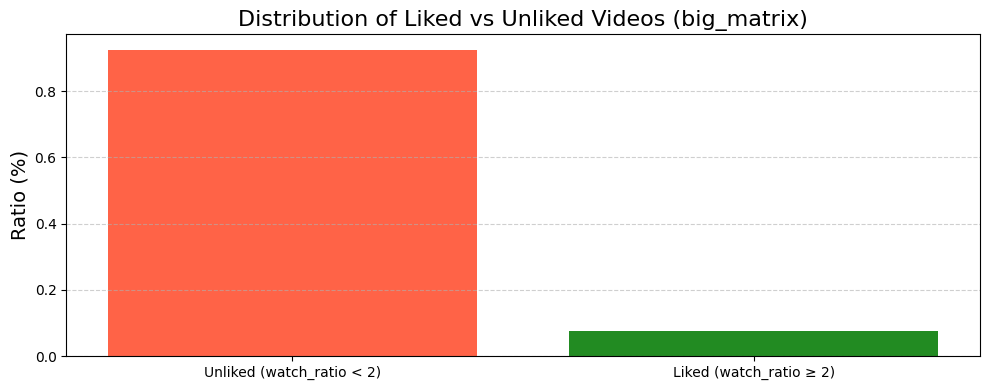

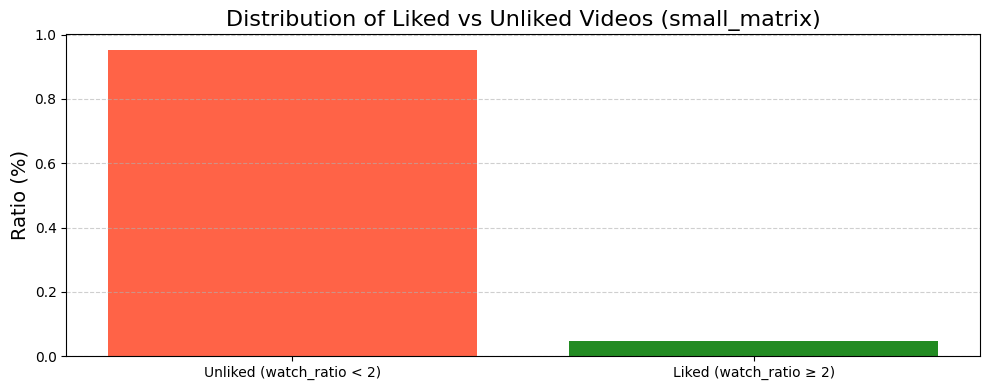

In [62]:
# Count classes
class_counts = (big_matrix['watch_ratio'] >= 2).astype(int).value_counts().sort_index()

# Map labels
labels = ['Unliked (watch_ratio < 2)', 'Liked (watch_ratio ≥ 2)']

plt.figure(figsize=(10, 4))
plt.bar(labels, class_counts.values / sum(class_counts.values), color=['tomato', 'forestgreen'])
plt.title('Distribution of Liked vs Unliked Videos (big_matrix)', fontsize=16)
plt.ylabel('Ratio (%)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Count classes
class_counts = (small_matrix['watch_ratio'] >= 2).astype(int).value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(labels, class_counts.values / sum(class_counts.values), color=['tomato', 'forestgreen'])
plt.title('Distribution of Liked vs Unliked Videos (small_matrix)', fontsize=16)
plt.ylabel('Ratio (%)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In both datasets, approximately 85-90% of interactions are "unliked," while only about 10-15% are classified as "liked." This imbalance reflects that most videos are not watched extensively, with a smaller portion receiving strong positive engagement.

The similarity in class distribution between the training and evaluation sets reinforces that the evaluation data is representative of the training data, which is important for reliable model assessment.

An important implication of the relatively small proportion of "like" signals is that if the recommender system relies solely on these positive interactions, the resulting user-item matrix will be extremely sparse. Since the underlying interaction matrix is already sparse, this sparsity could pose challenges for learning effective recommendations and may require additional strategies such as incorporating implicit feedback or data augmentation.